In [1]:
import torch
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from DeepRUOT.models import FNet

d:\program files\lib\site-packages\ot\backend.py:2998: UserWarning: To use TensorflowBackend, you need to activate the tensorflow numpy API. You can activate it by running: 
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
  register_backend(TensorflowBackend())


In [2]:
data = pd.read_csv('data/gaussian_1000d.csv')
t = X = np.array(data)[:, 1]
X = np.array(data)[:, 1:]

In [3]:
wfr_model = torch.load('results/pretrain_best_model', map_location=torch.device('cpu'))
wfr_model = FNet(in_out_dim=1000, hidden_dim=256, n_hiddens=5, activation='leakyrelu')
wfr_model.load_state_dict(torch.load('results/pretrain_best_model', map_location=torch.device('cpu')))
usb_model = torch.load('results/gaussian_1.3.pth', map_location=torch.device('cpu'), weights_only=False)

In [4]:
_,g_wfr,_,_ = wfr_model(torch.tensor(t, dtype = torch.float32).reshape(-1, 1), torch.tensor(X, dtype = torch.float32))
g_usb = usb_model.k_net(torch.concatenate([torch.tensor(X, dtype = torch.float32), torch.tensor(t, dtype = torch.float32).reshape(-1, 1)], dim=-1))
g_wfr = g_wfr.reshape(-1,).detach().numpy()
g_usb = g_usb.reshape(-1,).detach().numpy()

0.9024357968216593


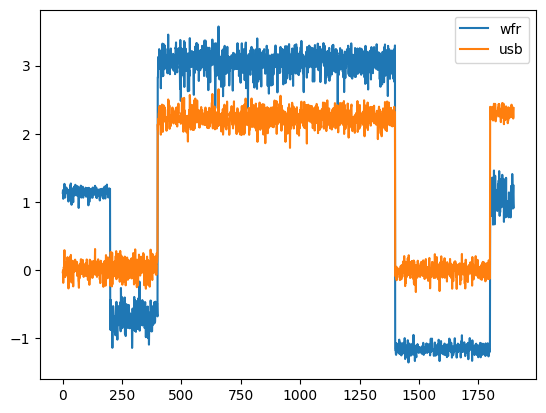

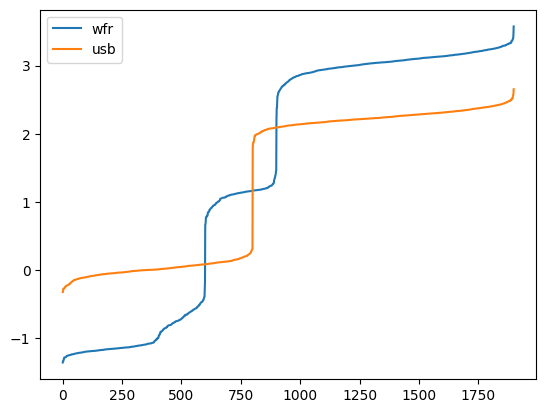

In [5]:
g_wfr_sorted = np.sort(g_wfr)
g_usb_sorted = np.sort(g_usb)

print(np.corrcoef(g_usb,g_wfr)[0,1])

plt.plot(g_wfr,label='wfr')
plt.plot(g_usb,label='usb')
plt.legend()
plt.show()

plt.plot(g_wfr_sorted,label='wfr')
plt.plot(g_usb_sorted,label='usb')
plt.legend()
plt.show()

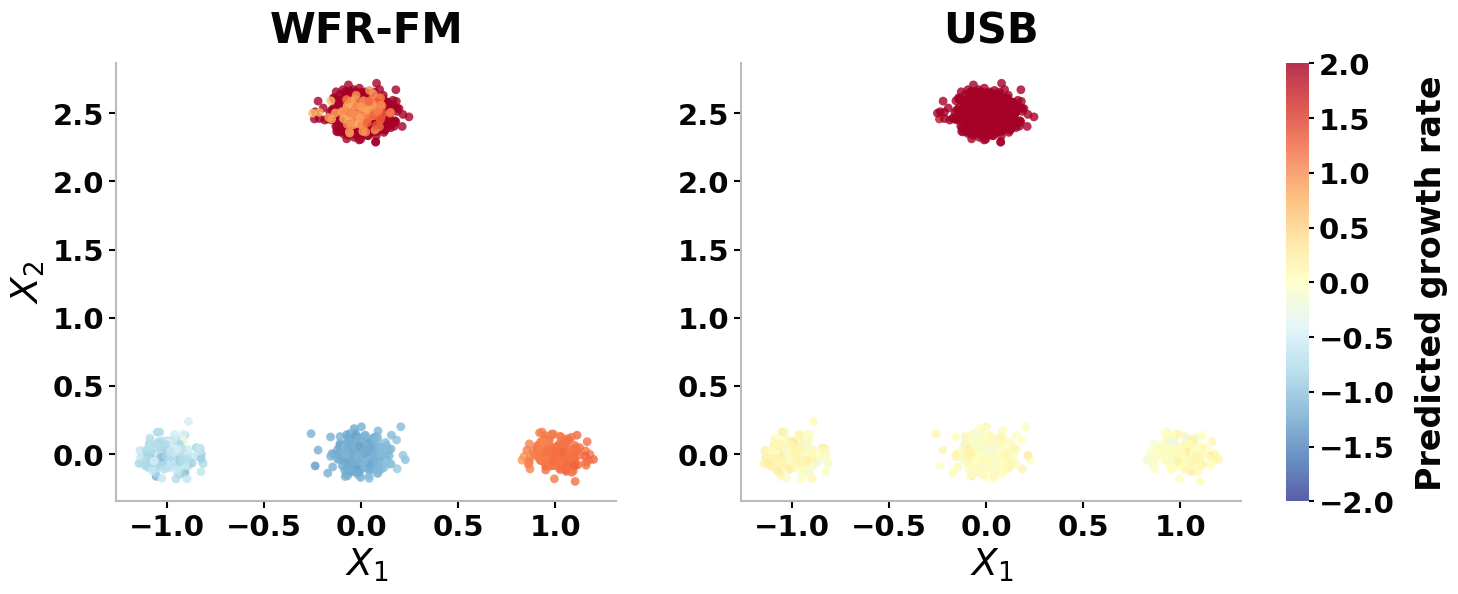

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 模拟数据 (替换为你的真实数据)
# X = ...
# g_wfr = ...
# g_usb = ...

# 计算公共范围
combined_data = np.concatenate([g_wfr, g_usb])
# 范围稍微缩一点，让高亮部分更明显，配色更好看
vmin = np.percentile(combined_data, 2)
vmax = np.percentile(combined_data, 98)
cmap_style = 'RdYlBu_r' 

# 定义字体大小配置
FONT_TITLE = 30
FONT_LABEL = 27
FONT_TICK = 21

fig, axs = plt.subplots(1, 2, figsize=(15, 6)) #稍微调高一点高度以适应大字体

# 调整布局：右侧预留空间给Colorbar，底部预留空间给大字体标签
plt.subplots_adjust(left=0.10, right=0.85, wspace=0.25, bottom=0.15, top=0.88)

def style_axis_bold(ax):
    # --- 边框样式 ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BBBBBB')
    ax.spines['left'].set_linewidth(1.5) # 边框也稍微加粗
    ax.spines['bottom'].set_color('#BBBBBB')
    ax.spines['bottom'].set_linewidth(1.5)
    
    # --- 刻度样式 (加大加粗) ---
    ax.tick_params(axis='both', colors="#050505", width=1.5, length=5)
    # 遍历刻度标签进行加粗和放大
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(FONT_TICK)
        label.set_fontweight('bold')

# 2. 绘制第一张图 (WFR)
sc1 = axs[0].scatter(X[:, 0], X[:, 1], c=g_wfr, cmap=cmap_style, 
                     vmin=-2, vmax=2, s=40, alpha=0.8, edgecolor='none')

axs[0].set_title('WFR-FM', color="#050505", fontsize=FONT_TITLE, fontweight='bold', pad=15)
axs[0].set_xlabel('$X_1$', fontsize=FONT_LABEL, fontweight='bold')
axs[0].set_ylabel('$X_2$', fontsize=FONT_LABEL, fontweight='bold')
style_axis_bold(axs[0])

# 3. 绘制第二张图 (USB)
sc2 = axs[1].scatter(X[:, 0], X[:, 1], c=g_usb, cmap=cmap_style, 
                     vmin=-2, vmax=2, s=40, alpha=0.8, edgecolor='none')

axs[1].set_title('USB', color="#050505", fontsize=FONT_TITLE, fontweight='bold', pad=15)
axs[1].set_xlabel('$X_1$', fontsize=FONT_LABEL, fontweight='bold')
# axs[1].set_ylabel('$X_2$') 
style_axis_bold(axs[1])

# 4. 手动指定 Colorbar 位置 (防止重叠)
# [left, bottom, width, height]
cax = fig.add_axes([0.88, 0.15, 0.015, 0.73]) 

cbar = fig.colorbar(sc1, cax=cax) 
cbar.set_label('Predicted growth rate', color="#050505", fontsize=24, fontweight='bold', labelpad=15)
cbar.outline.set_visible(False) # 去外框

# Colorbar 刻度也要加大加粗
cbar.ax.tick_params(color="#050505", width=1.5)
for label in cbar.ax.get_yticklabels():
    label.set_fontsize(FONT_TICK)
    label.set_fontweight('bold')
    label.set_color("#050505")

plt.savefig('results/Gaussian_growth_comparison2.png')
plt.show()